In [20]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import compress_pickle as pickle  
import mplhep as hep
import math
from scipy.optimize import curve_fit
import compress_pickle
import pickle
import gzip
hep.style.use("CMS")
from helpers import *

In [21]:
path_to_result = "/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_DIS_results/testing_dis/"

In [22]:
# Will likely need to change name of npz file for your use case
npz_unpacked = np.load(path_to_result+"/predictions_appended_test.npz", allow_pickle=True) 
predictions_unnormalized = npz_unpacked['outputs_scaled'].item()
targets_unnormalized = npz_unpacked['targets_scaled'].item()

targets_E_minus_pz = targets_unnormalized["E_minus_pz"]
targets_pt = targets_unnormalized["transverse_momentum"]

predictions_E_minus_pz = predictions_unnormalized["E_minus_pz"]
predictions_pt = predictions_unnormalized["transverse_momentum"]

meta_info = npz_unpacked['meta']

Text(0, 1, 'Counts (log)')

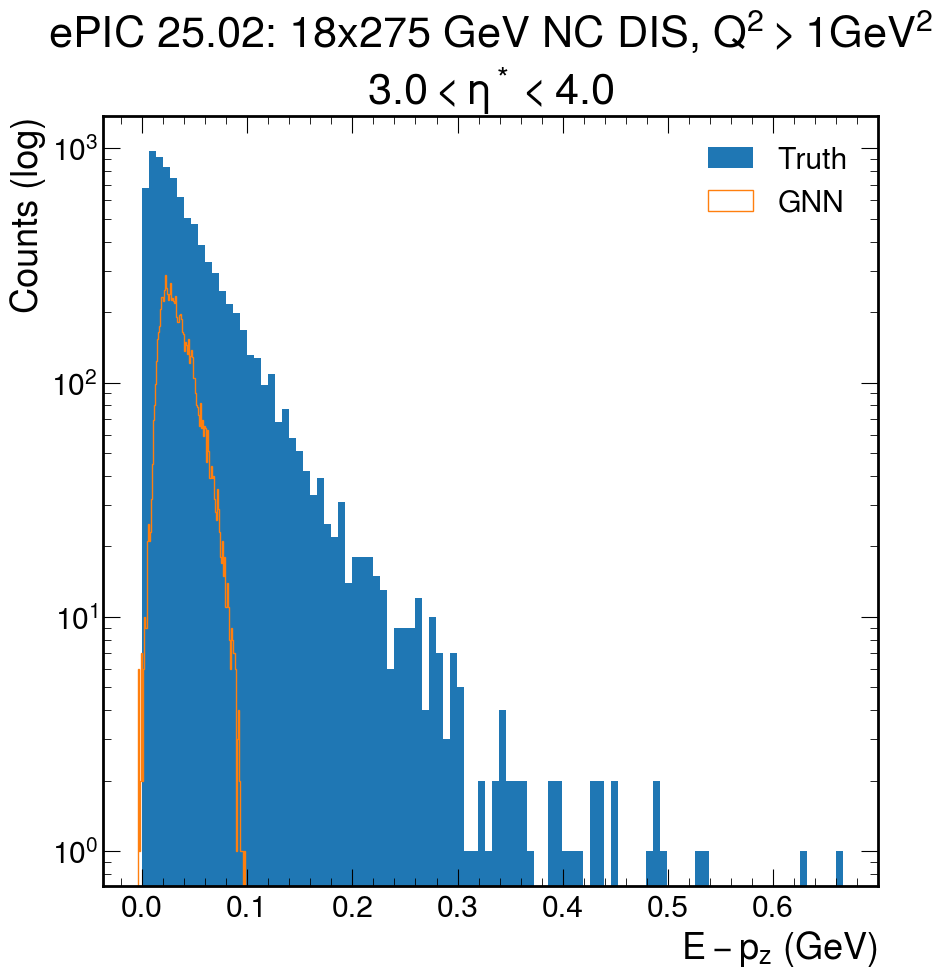

In [23]:
plt.hist(targets_E_minus_pz, bins=100, label="Truth")
plt.hist(predictions_E_minus_pz, bins=100, label="GNN", histtype='step')
plt.xlabel("$E-p_z$ (GeV)")
plt.yscale('log')
plt.title("ePIC 25.02: 18x275 GeV NC DIS, $Q^2 > 1 GeV^2$\n$3.0<\eta^*<4.0$")
plt.legend()
plt.ylabel("Counts (log)")

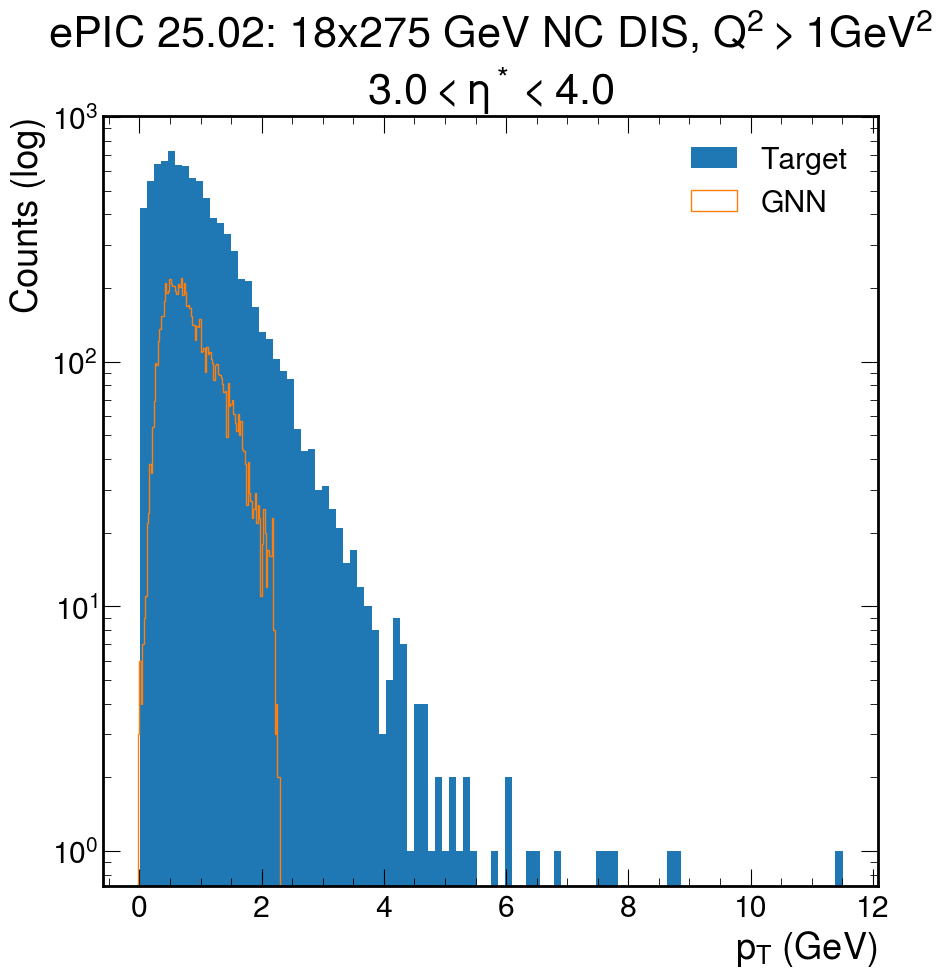

In [24]:
plt.hist(targets_pt, bins=100, label="Target")
plt.hist(predictions_pt, bins=100, label="GNN", histtype='step')
plt.xlabel("$p_{T}$ (GeV)")
plt.yscale('log')
plt.title("ePIC 25.02: 18x275 GeV NC DIS, $Q^2 > 1 GeV^2$\n$3.0<\eta^*<4.0$")
plt.ylabel("Counts (log)")
plt.legend()

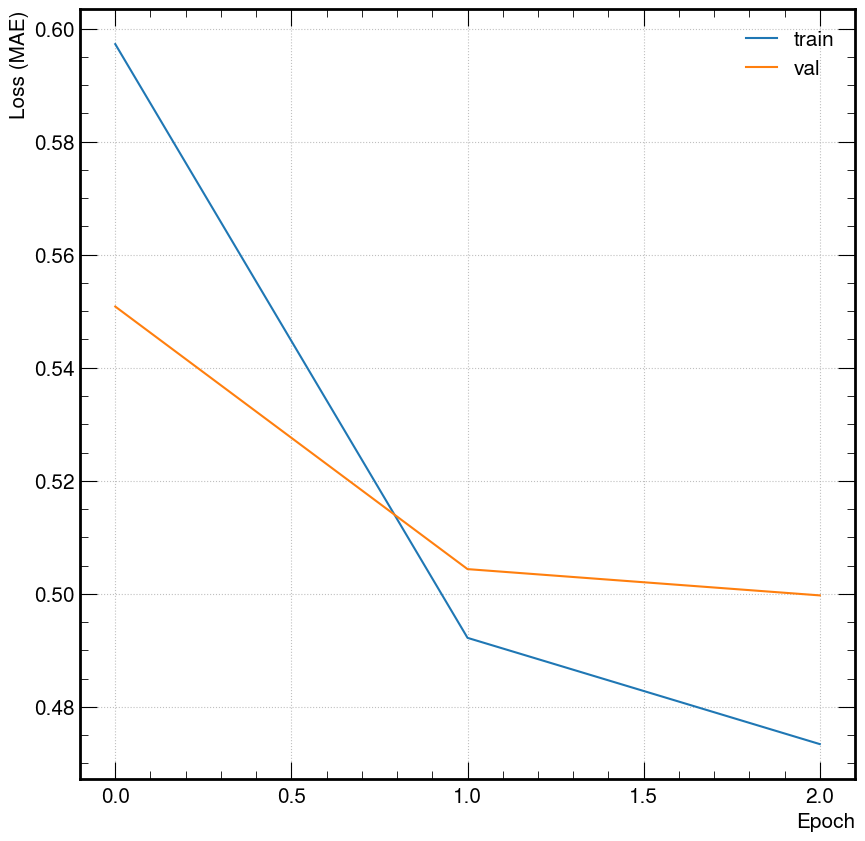

In [25]:
npz_unpacked_loss = np.load(path_to_result + "/losses.npz")

train_loss = npz_unpacked_loss['training']
val_loss = npz_unpacked_loss['validation']

val_mean_loss=np.mean(val_loss, axis=1)
train_mean_loss=np.mean(train_loss, axis=1)

plt.plot(train_mean_loss,label='train')

plt.plot(val_mean_loss, label='val')
plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss (MAE)", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()